In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import gseapy as gp
import os
import pickle

import subcluster_funcs as funcs
sc._settings.settings._vector_friendly=True

import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

In [2]:
post_subclustering_dir = "../post_subcluster_annotation/"
os.makedirs(post_subclustering_dir, exist_ok=True)

In [3]:
cell_type = "Cardiomyocyte"

In [4]:
adata = sc.read_h5ad("../post_subclustering/" + cell_type  + ".h5ad")

<Axes: xlabel='leiden', ylabel='sil_score'>

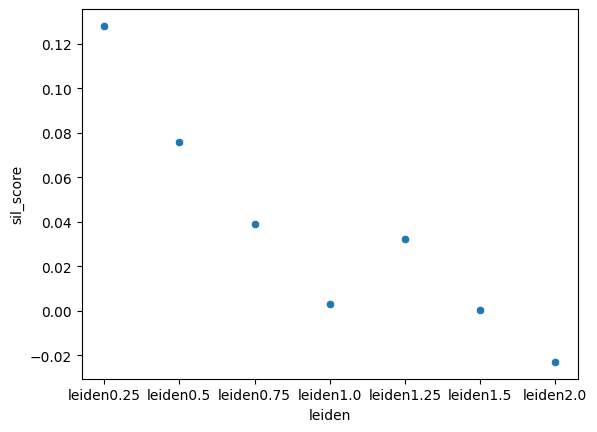

In [5]:
funcs.silhouette(adata, cell_type = cell_type)

### Leiden 0.25

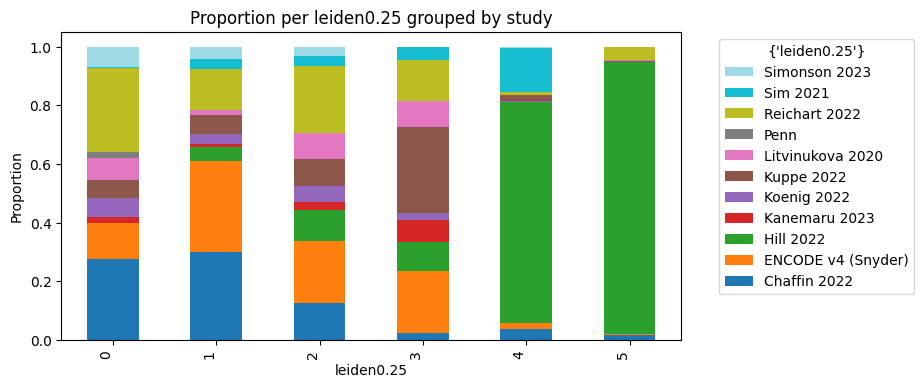

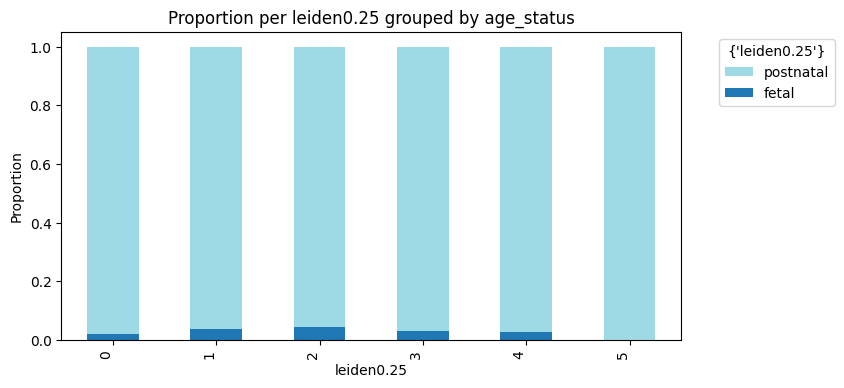

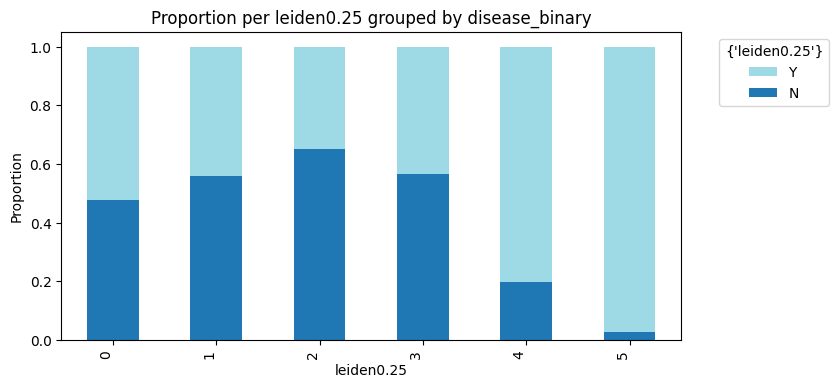

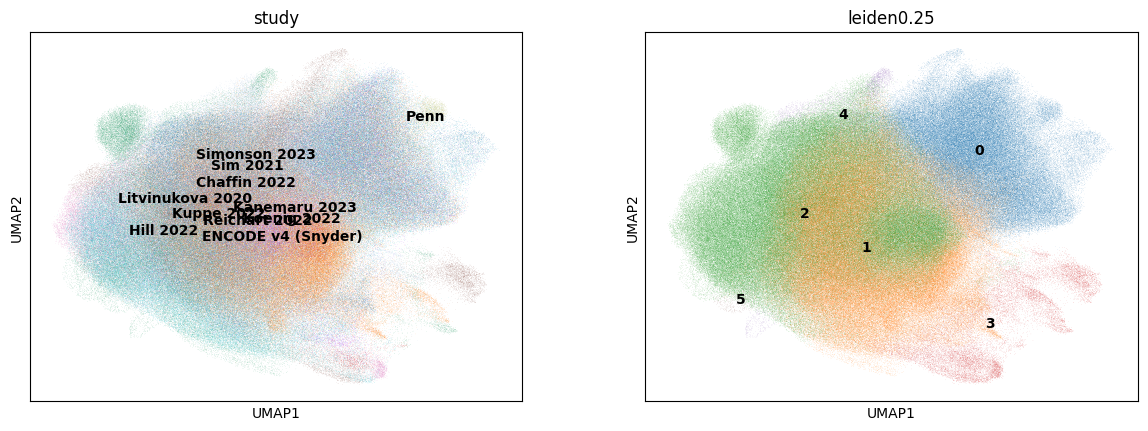

/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:458: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:459: RuntimeWarning: overflow encountered in expm1
  self.expm1_func(mean_rest) + 1e-9
/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:458: RuntimeWarning: invalid value encountered in divide
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: divide by zero encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:458: RuntimeWarning: overflow encountered in expm1
  foldchanges = (sel

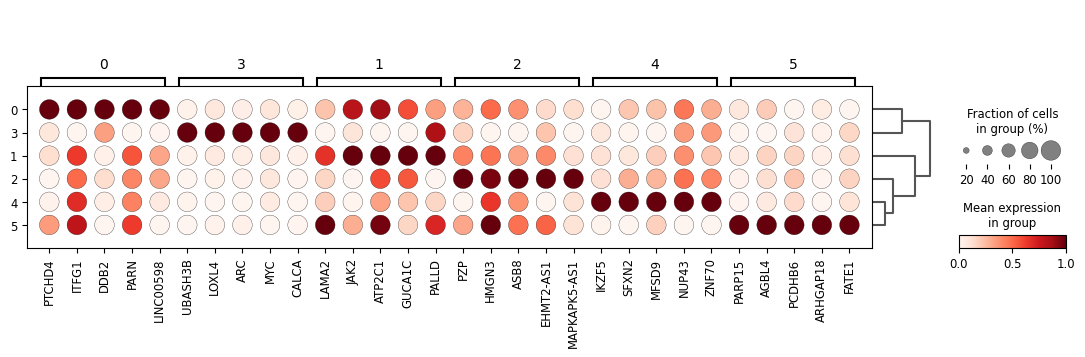

Counter({'2': 271450, '1': 236397, '0': 144086, '3': 18883, '4': 5343, '5': 495})


['leiden0.25',
 AnnData object with n_obs × n_vars = 676654 × 16115
     obs: 'age', 'donor_id', 'sex', 'region', 'cell_type', 'disease', 'consistent_cell_type', 'study', 'technology', 'cell_or_nuclei', 'barcode', 'sample_id', 'age_status', 'tech_plus_study', 'disease_binary', 'decade', 'age_group', '_scvi_batch', '_scvi_labels', 'leiden_scVI', 'scvi_cell_type', 'redo_leiden_0.5', 'UMAP1', 'UMAP2', 'v2_scvi_cell_type', 'final_cell_type', 'leiden0.1', 'leiden0.25', 'leiden0.5', 'leiden0.75', 'leiden1.0', 'leiden1.25', 'leiden1.5', 'leiden1.75', 'leiden2.0'
     var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
     uns: '_scvi_manager_uuid', '_scvi_uuid', 'hvg', 'leiden0.1', 'leiden0.25', 'leiden0.5', 'leiden0.75', 'leiden1.0', 'leiden1.25', 'leiden1.5', 'leiden1.75', 'leiden2.0', 'neighbors', 'pca', 'rank_genes_groupsleiden0.1', 'rank_genes_groupsleiden0.25', 'rank_genes_groupsleiden0.5', 'rank_genes_groupsleiden0.75', 'rank_genes_groupsleiden1.0', 

In [6]:
funcs.specify_leiden_subclustering(adata=adata, leiden="leiden0.25")

- Cluster 0 include DNA damage/senescence markers: PTCHD4/ATM/DDB2
- Cluster 1 and 2 are the main CM clusters, with many contractile markers (MYH7/CASQ2)
- Cluster 3 are remodeling CMs (MYC/LOXL4/SPHK1)
- Clusters 4 and 5 are primarily from one study

In [19]:
sc.get.rank_genes_groups_df(adata, group="0").head(50)['names']

0        PTCHD4
1         ITFG1
2          DDB2
3          PARN
4     LINC00598
5       FAM120B
6      C1orf112
7           ATM
8         ASTN2
9       ERCC6L2
10        UNC79
11      DNAJC15
12        YLPM1
13         SLPI
14        TMLHE
15         LMF1
16        SUGCT
17         ELP4
18      GALNT10
19      TBC1D32
20       TRIM66
21       MT-ND5
22        PSMA1
23        ITM2A
24          FTO
25        SNRPN
26       CYFIP2
27        TFCP2
28     SLC25A21
29      DYNC2H1
30      ZDHHC20
31        ITLN1
32       SUCLA2
33        CHODL
34      SCGB2B2
35        CKAP5
36       MT-ND6
37        COX6C
38         TPK1
39        ACTA2
40         DHFR
41       MT-CYB
42    LINC00589
43        LTBP3
44       ATP1A4
45         MAOB
46     KIAA1328
47       MT-CO3
48       GLCCI1
49      RANBP17
Name: names, dtype: object

In [13]:
adata.obs['subcluster'] = adata.obs['leiden0.25'].map(
    {"0": "Senescent",
     "1": "Mature",
     "2": "Mature",
     "3": "Immature",
     "4": "Mature",
     "5": "Mature",
    }
)

In [14]:
subcluster_order = [
    "Senescent",
    "Mature",
    "Immature",
]

adata.obs['subcluster'] = pd.Categorical(
    adata.obs['subcluster'], categories=subcluster_order, ordered=True
)

# Define colors for each CM subcluster
subcluster_colors = {
    "Senescent": "pink",       # gold
    "Mature": "red",    # red
    "Immature": "blue",   # blue
}

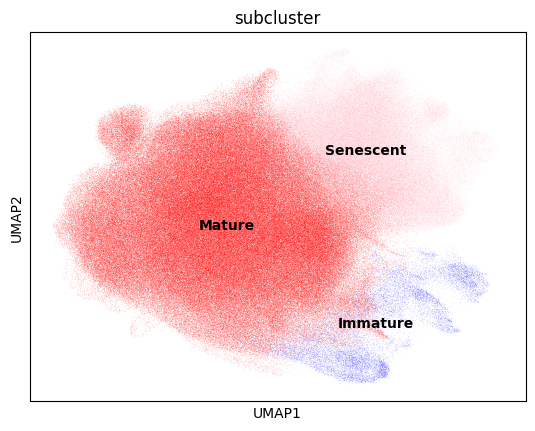

In [15]:
with plt.rc_context(): 
    sc.pl.umap(adata, color = ['subcluster'], legend_loc = "on data", palette=subcluster_colors, show=False)
    plt.savefig("CM_subclustered.pdf", bbox_inches="tight")

In [16]:
#sc.pl.umap(adata, color = ['subcluster'], legend_loc = "on data", palette=subcluster_colors)

#sc.pl.umap(
#    adata[adata.obs['subcluster'] != 'Other'],
#    color='subcluster',
#    palette={k:v for k,v in subcluster_colors.items() if k != "Other"},
#    size=0.2
#)

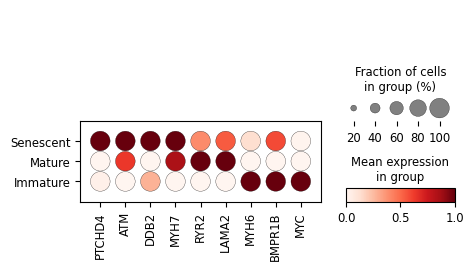

In [17]:
with plt.rc_context(): 
    sc.pl.dotplot(adata, var_names = ["PTCHD4", "ATM", "DDB2",
                                      "MYH7", "RYR2", "LAMA2",
                                      "MYH6", "BMPR1B", "MYC"], groupby = "subcluster",
                  standard_scale='var', show=False)
    plt.savefig("CM_subclustered_dotplot.pdf", bbox_inches="tight")

In [18]:
subcluster_stats = (
    adata.obs['subcluster']
    .value_counts(normalize=False)
    .rename("count")
    .reset_index()
    .rename(columns={"index": "subcluster"})
)

subcluster_stats["proportion"] = subcluster_stats["count"] / subcluster_stats["count"].sum()

print(subcluster_stats)

  subcluster   count  proportion
0     Mature  513685    0.759155
1  Senescent  144086    0.212939
2   Immature   18883    0.027906
